# What is an MLP?

MLP = Multi-Layer Perceptron

A Multi-Layer Perceptron is a neural network that contains:

1. Input Layer
2. One or More Hidden Layers
3. Output Layer

The purpose of hidden layers is to learn increasingly complex patterns.

More hidden layers = ability to learn more complex relationships.

In [3]:
import base64
from IPython.display import Image, display

def render_mermaid(code):
    base64_str = base64.b64encode(code.encode('utf-8')).decode('utf-8')
    display(Image(url="https://mermaid.ink/img/" + base64_str))


In [5]:
mer1="""
flowchart LR

    X1[Hours Studied]
    X2[Attendance]

    H11((H1))
    H12((H2))

    H21((H3))
    H22((H4))

    O((Pass Probability))

    X1 --> H11
    X1 --> H12

    X2 --> H11
    X2 --> H12

    H11 --> H21
    H11 --> H22

    H12 --> H21
    H12 --> H22

    H21 --> O
    H22 --> O

    O --> D{Probability > 0.5?}

    D -->|Yes| P[Pass]
    D -->|No| F[Fail]
"""
render_mermaid(mer1)

## Understanding the Layers

Input Layer:
Receives raw features.

Hidden Layer 1:
Learns simple patterns.

Hidden Layer 2:
Combines simple patterns into more meaningful patterns.

Output Layer:
Produces final prediction.

Example:

Hours Studied = 8
Attendance = 90

Output:
Probability of Passing = 0.92

In [9]:
!pip install numpy==1.26.4
!pip install tensorflow==2.19.0


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
data = pd.DataFrame({
    "Hours_Studied":[1,2,3,4,5,6,7,8],
    "Attendance":[40,50,55,60,70,80,85,95],
    "Passed":[0,0,0,0,1,1,1,1]
})

data

,Hours_Studied,Attendance,Passed
0,1,40,0
1,2,50,0
2,3,55,0
3,4,60,0
4,5,70,1
5,6,80,1
6,7,85,1
7,8,95,1


In [4]:
X = data[["Hours_Studied","Attendance"]]

y = data["Passed"]

print(X)
print(y)

   Hours_Studied  Attendance
0              1          40
1              2          50
2              3          55
3              4          60
4              5          70
5              6          80
6              7          85
7              8          95
0    0
1    0
2    0
3    0
4    1
5    1
6    1
7    1
Name: Passed, dtype: int64


In [5]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled)

[[0.         0.        ]
 [0.14285714 0.18181818]
 [0.28571429 0.27272727]
 [0.42857143 0.36363636]
 [0.57142857 0.54545455]
 [0.71428571 0.72727273]
 [0.85714286 0.81818182]
 [1.         1.        ]]


In [6]:
model = Sequential([
    
    Dense(2, activation='relu', input_shape=(2,)),
    
    Dense(2, activation='relu'),
    
    Dense(1, activation='sigmoid')
])

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 6         
                                                                 
 dense_1 (Dense)             (None, 2)                 6         
                                                                 
 dense_2 (Dense)             (None, 1)                 3         
                                                                 
Total params: 15 (60.00 Byte)
Trainable params: 15 (60.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [11]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    X_scaled,
    y,
    epochs=200,
    verbose=1
)

print("Training Complete")

Epoch 1/200
1/1 [==============================] - 0s 366ms/step - loss: 0.3405 - accuracy: 1.0000
Epoch 2/200
1/1 [==============================] - 0s 17ms/step - loss: 0.3396 - accuracy: 1.0000
Epoch 3/200
1/1 [==============================] - 0s 14ms/step - loss: 0.3388 - accuracy: 1.0000
Epoch 4/200
1/1 [==============================] - 0s 0s/step - loss: 0.3379 - accuracy: 1.0000
Epoch 5/200
1/1 [==============================] - 0s 18ms/step - loss: 0.3371 - accuracy: 1.0000
Epoch 6/200
1/1 [==============================] - 0s 11ms/step - loss: 0.3362 - accuracy: 1.0000
Epoch 7/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3354 - accuracy: 1.0000
Epoch 8/200
1/1 [==============================] - 0s 11ms/step - loss: 0.3345 - accuracy: 1.0000
Epoch 9/200
1/1 [==============================] - 0s 0s/step - loss: 0.3336 - accuracy: 1.0000
Epoch 10/200
1/1 [==============================] - 0s 11ms/step - loss: 0.3328 - accuracy: 1.0000
Epoch 11/200
1/1 [=====

1/1 [==============================] - 0s 0s/step - loss: 0.2723 - accuracy: 1.0000
Epoch 85/200
1/1 [==============================] - 0s 5ms/step - loss: 0.2715 - accuracy: 1.0000
Epoch 86/200
1/1 [==============================] - 0s 0s/step - loss: 0.2708 - accuracy: 1.0000
Epoch 87/200
1/1 [==============================] - 0s 4ms/step - loss: 0.2700 - accuracy: 1.0000
Epoch 88/200
1/1 [==============================] - 0s 0s/step - loss: 0.2692 - accuracy: 1.0000
Epoch 89/200
1/1 [==============================] - 0s 9ms/step - loss: 0.2685 - accuracy: 1.0000
Epoch 90/200
1/1 [==============================] - 0s 0s/step - loss: 0.2677 - accuracy: 1.0000
Epoch 91/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2670 - accuracy: 1.0000
Epoch 92/200
1/1 [==============================] - 0s 3ms/step - loss: 0.2662 - accuracy: 1.0000
Epoch 93/200
1/1 [==============================] - 0s 0s/step - loss: 0.2655 - accuracy: 1.0000
Epoch 94/200
1/1 [====================

1/1 [==============================] - 0s 0s/step - loss: 0.2150 - accuracy: 1.0000
Epoch 168/200
1/1 [==============================] - 0s 11ms/step - loss: 0.2144 - accuracy: 1.0000
Epoch 169/200
1/1 [==============================] - 0s 0s/step - loss: 0.2138 - accuracy: 1.0000
Epoch 170/200
1/1 [==============================] - 0s 0s/step - loss: 0.2132 - accuracy: 1.0000
Epoch 171/200
1/1 [==============================] - 0s 10ms/step - loss: 0.2126 - accuracy: 1.0000
Epoch 172/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2120 - accuracy: 1.0000
Epoch 173/200
1/1 [==============================] - 0s 10ms/step - loss: 0.2114 - accuracy: 1.0000
Epoch 174/200
1/1 [==============================] - 0s 6ms/step - loss: 0.2108 - accuracy: 1.0000
Epoch 175/200
1/1 [==============================] - 0s 0s/step - loss: 0.2102 - accuracy: 1.0000
Epoch 176/200
1/1 [==============================] - 0s 0s/step - loss: 0.2096 - accuracy: 1.0000
Epoch 177/200
1/1 [=======

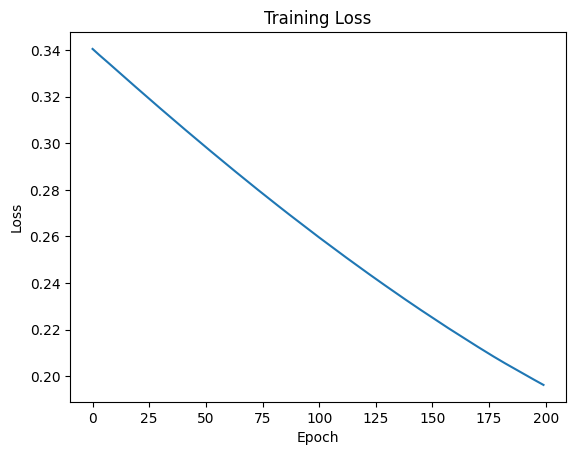

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [14]:
predictions = model.predict(X_scaled)

print(predictions)

1/1 [==============================] - 0s 80ms/step
[[0.0592223 ]
 [0.0843778 ]
 [0.18237604]
 [0.35241997]
 [0.65026313]
 [0.8638815 ]
 [0.88463485]
 [0.9221381 ]]


In [15]:
predicted_classes = (predictions > 0.5).astype(int)

print(predicted_classes)

[[0]
 [0]
 [0]
 [0]
 [1]
 [1]
 [1]
 [1]]


In [16]:
results = pd.DataFrame({
    "Actual": y,
    "Predicted": predicted_classes.flatten()
})

results

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,0,0
4,1,1
5,1,1
6,1,1
7,1,1


In [17]:
new_student = [[6,85]]

new_student_scaled = scaler.transform(new_student)

probability = model.predict(new_student_scaled)

print("Probability of Passing:", probability[0][0])

1/1 [==============================] - 0s 31ms/step
Probability of Passing: 0.8878804


C:\Users\Siddharth257535\AppData\Local\anaconda3\envs\tf_fraud\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 6         
                                                                 
 dense_1 (Dense)             (None, 2)                 6         
                                                                 
 dense_2 (Dense)             (None, 1)                 3         
                                                                 
Total params: 15 (60.00 Byte)
Trainable params: 15 (60.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
weights = model.get_weights()

for i, w in enumerate(weights):
    print(f"\nWeight Matrix {i+1}")
    print(w)


Weight Matrix 1
[[-1.1145409 -0.2458902]
 [ 0.2062957  1.6435541]]

Weight Matrix 2
[ 0.6466483  -0.22422785]

Weight Matrix 3
[[ 1.863643  -1.1697271]
 [-0.7536288  1.4502989]]

Weight Matrix 4
[0.5977834  0.54979426]

Weight Matrix 5
[[-1.4853683]
 [ 1.1365951]]

Weight Matrix 6
[-0.08743075]
